In [1]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_real_world_j10_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(990, 8)


In [2]:
import re

case_config = r'/home/zzj/projects/FTSAD/supp_files/real_config_table_4_ipynb.csv'

case_data = pd.read_csv(case_config)

def get_seg_type(row):
    min_seg_len = row['min_seg_len']
    max_seg_len = row['max_seg_len']
    seg_type = f"{min_seg_len}-{max_seg_len}"
    return seg_type

case_data['seg_type'] = case_data.apply(get_seg_type, axis=1)



data_new = pd.merge(data, case_data, how='left', on='case_name')

# 把所有case_name 为NIPS_TS_Creditcard的名字改成Creditcard
data_new['case_name'] = data_new['case_name'].replace('NIPS_TS_Creditcard', 'Creditcard')
data_new = data_new[data_new['model_name'] != 'Random']

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
print(data_new.head())
print(data_new.columns)

  case_name model_name  case_seed metric_name  mean_val   std_val  \
0       MSL    Model10         42      AUC-PR  0.057350  0.000155   
1       MSL    Model10         42     AUC-ROC  0.099658  0.002740   
2       MSL    Model10         42      Aff-F1  0.613145  0.012296   
3       MSL    Model10         42          F1  0.008382  0.001684   
4       MSL    Model10         42       F1-PA  0.687022  0.045130   

   mean_latency  std_latency  ts_len  seg  max_seg_len  min_seg_len  \
0     11.210488     0.223674   73729   36         1141           11   
1     32.851632     1.189306   73729   36         1141           11   
2    389.613009     9.101273   73729   36         1141           11   
3     13.702560     0.218918   73729   36         1141           11   
4     40.736163     0.780118   73729   36         1141           11   

   avg_seg_len seg_type  
0   215.722222  11-1141  
1   215.722222  11-1141  
2   215.722222  11-1141  
3   215.722222  11-1141  
4   215.722222  11-1141  
In

[(4, '4 Segs (SMD-3-1)'), (8, '8 Segs (SMD-1-1)'), (13, '13 Segs (SMD-2-1)'), (35, '35 Segs (SWAT)'), (36, '36 Segs (MSL)'), (465, '465 Segs (Creditcard)')]
[4, 8, 13, 35, 36, 465]
['4', '8', '13', '35', '36', '465']


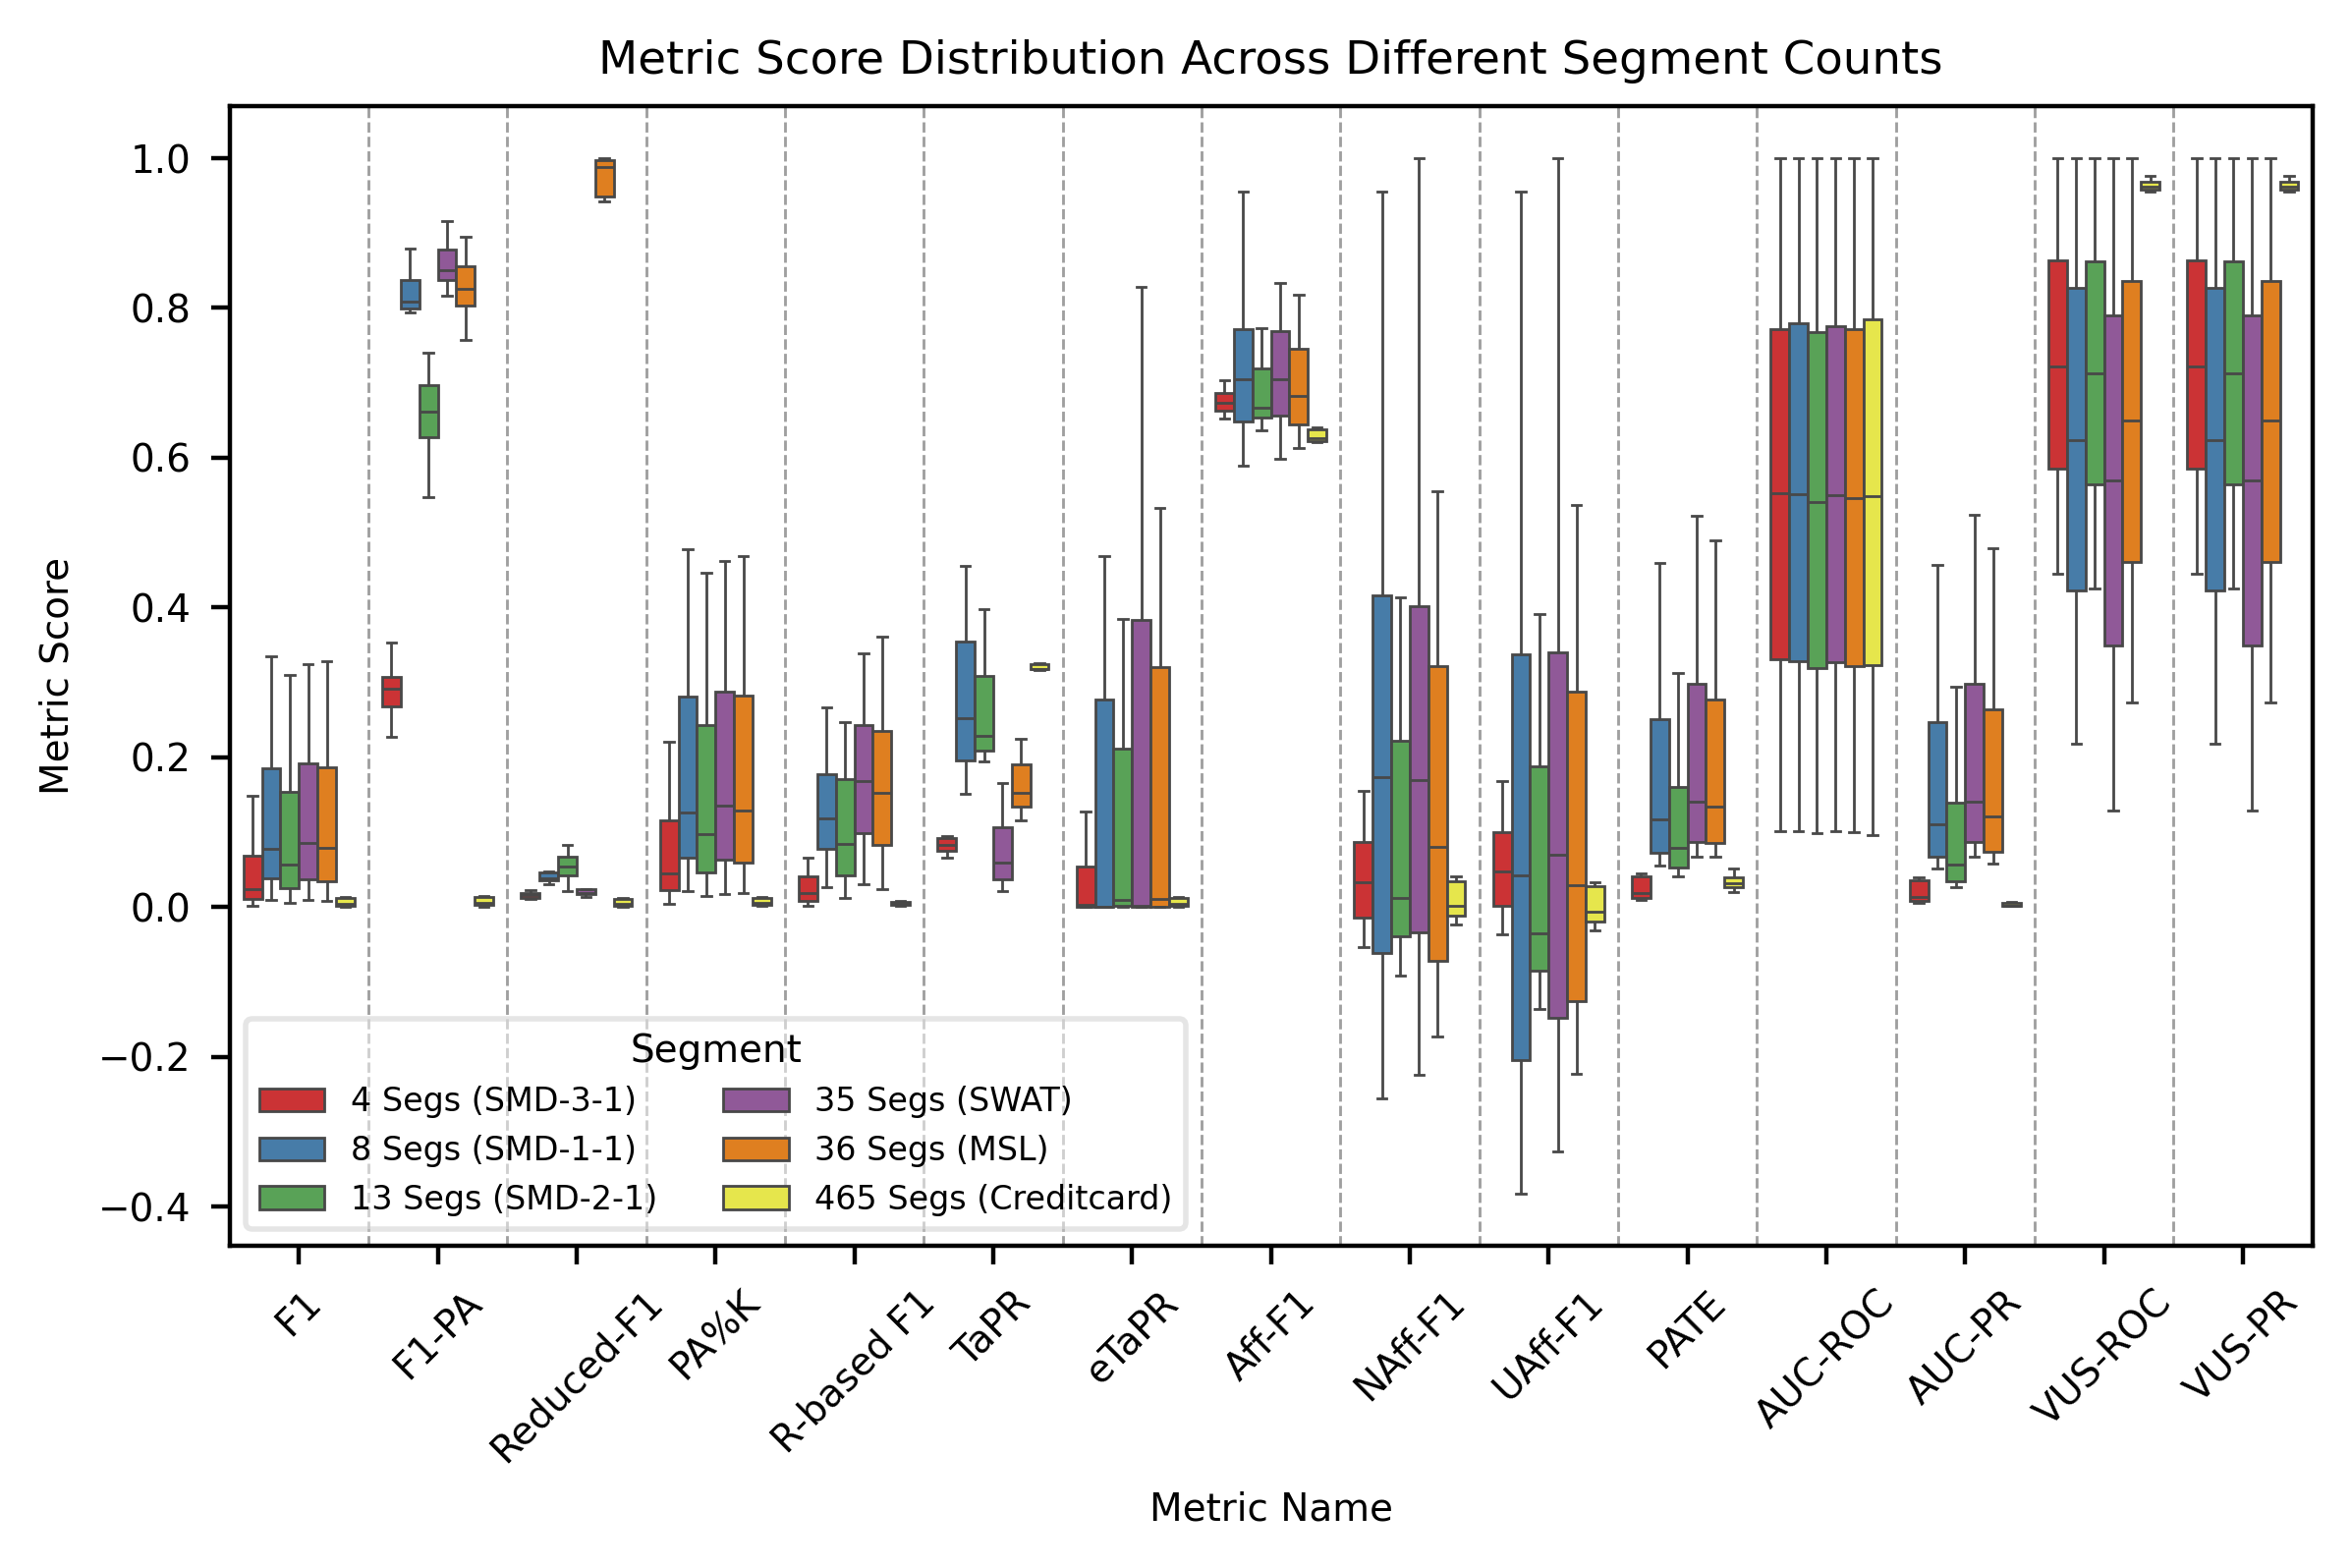

[(23694, '23694 (SMD-2-1)'), (28479, '28479 (SMD-1-1)'), (28700, '28700 (SMD-3-1)'), (73729, '73729 (MSL)'), (284807, '284807 (Creditcard)'), (449919, '449919 (SWAT)')]
[23694, 28479, 28700, 73729, 284807, 449919]
['11-1141', '1-5', '2-721', '8-452', '21-131', '101-35900']


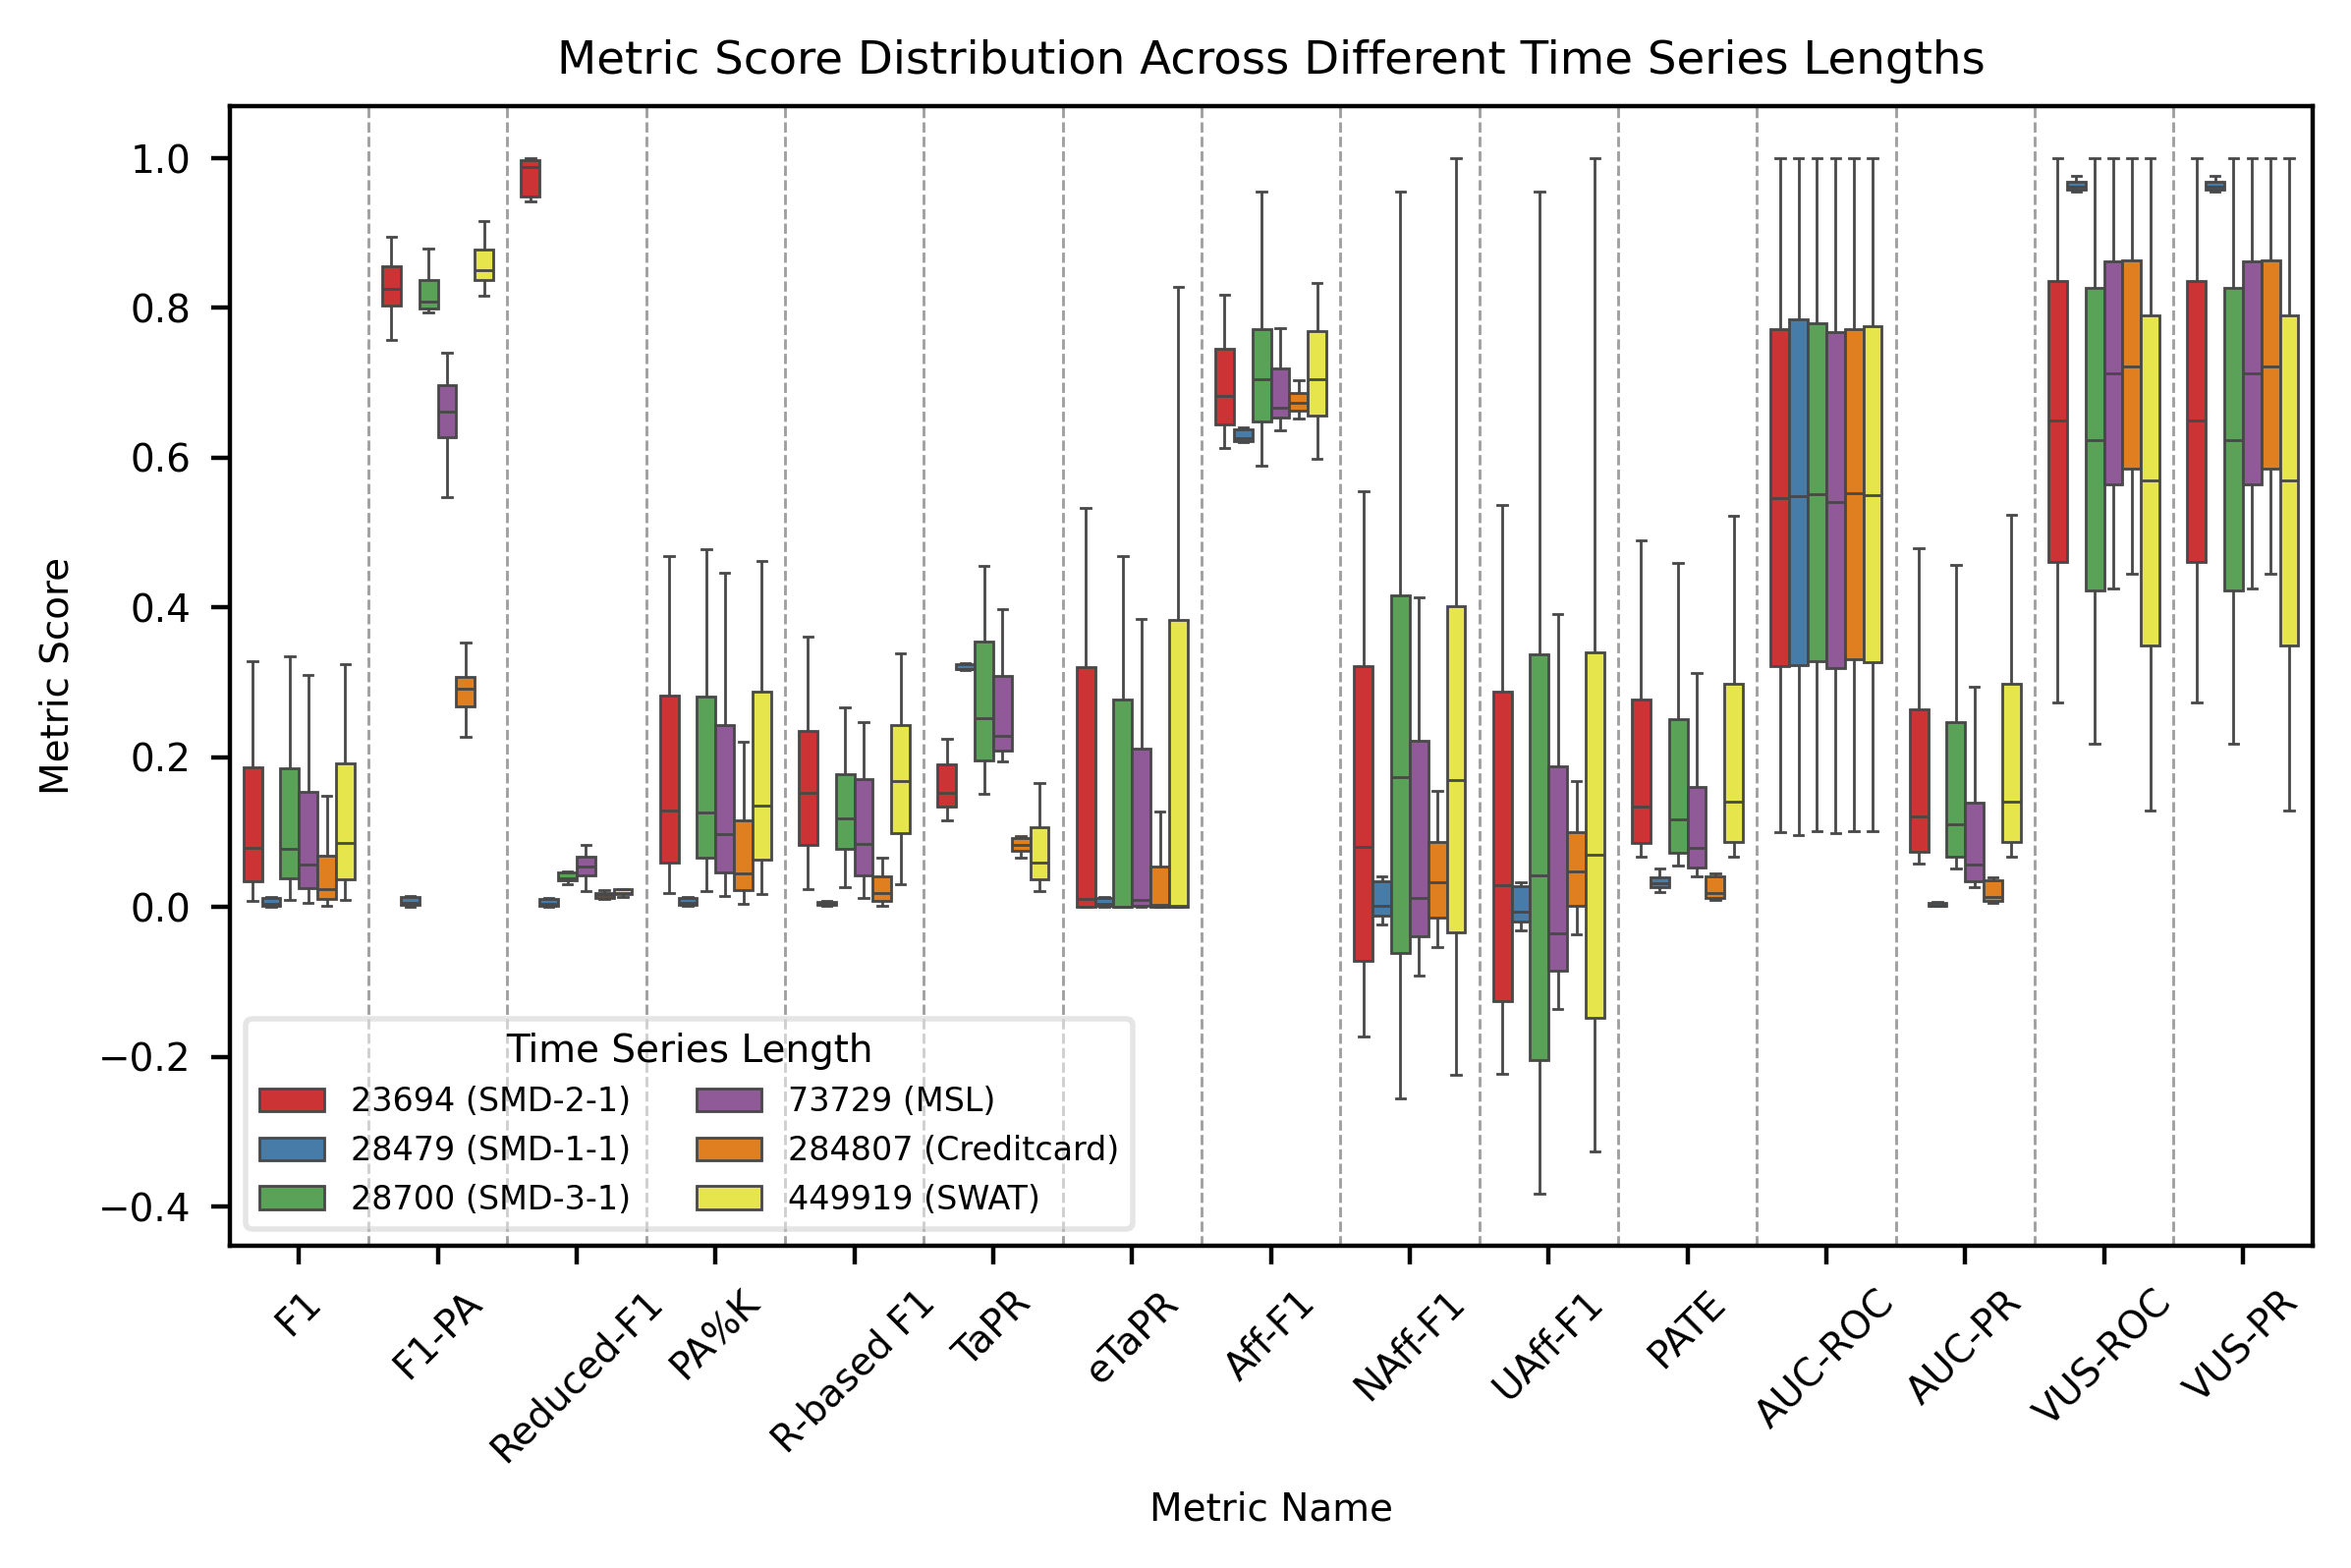

[(1.0580645161290323, '1.06 (Creditcard)'), (77.0, '77.0 (SMD-3-1)'), (90.0, '90.0 (SMD-2-1)'), (215.72222222222223, '215.72 (MSL)'), (336.75, '336.75 (SMD-1-1)'), (1560.6, '1560.6 (SWAT)')]
[1.0580645161290323, 77.0, 90.0, 215.72222222222223, 336.75, 1560.6]
['1.0580645161290323', '77.0', '90.0', '215.72222222222223', '336.75', '1560.6']


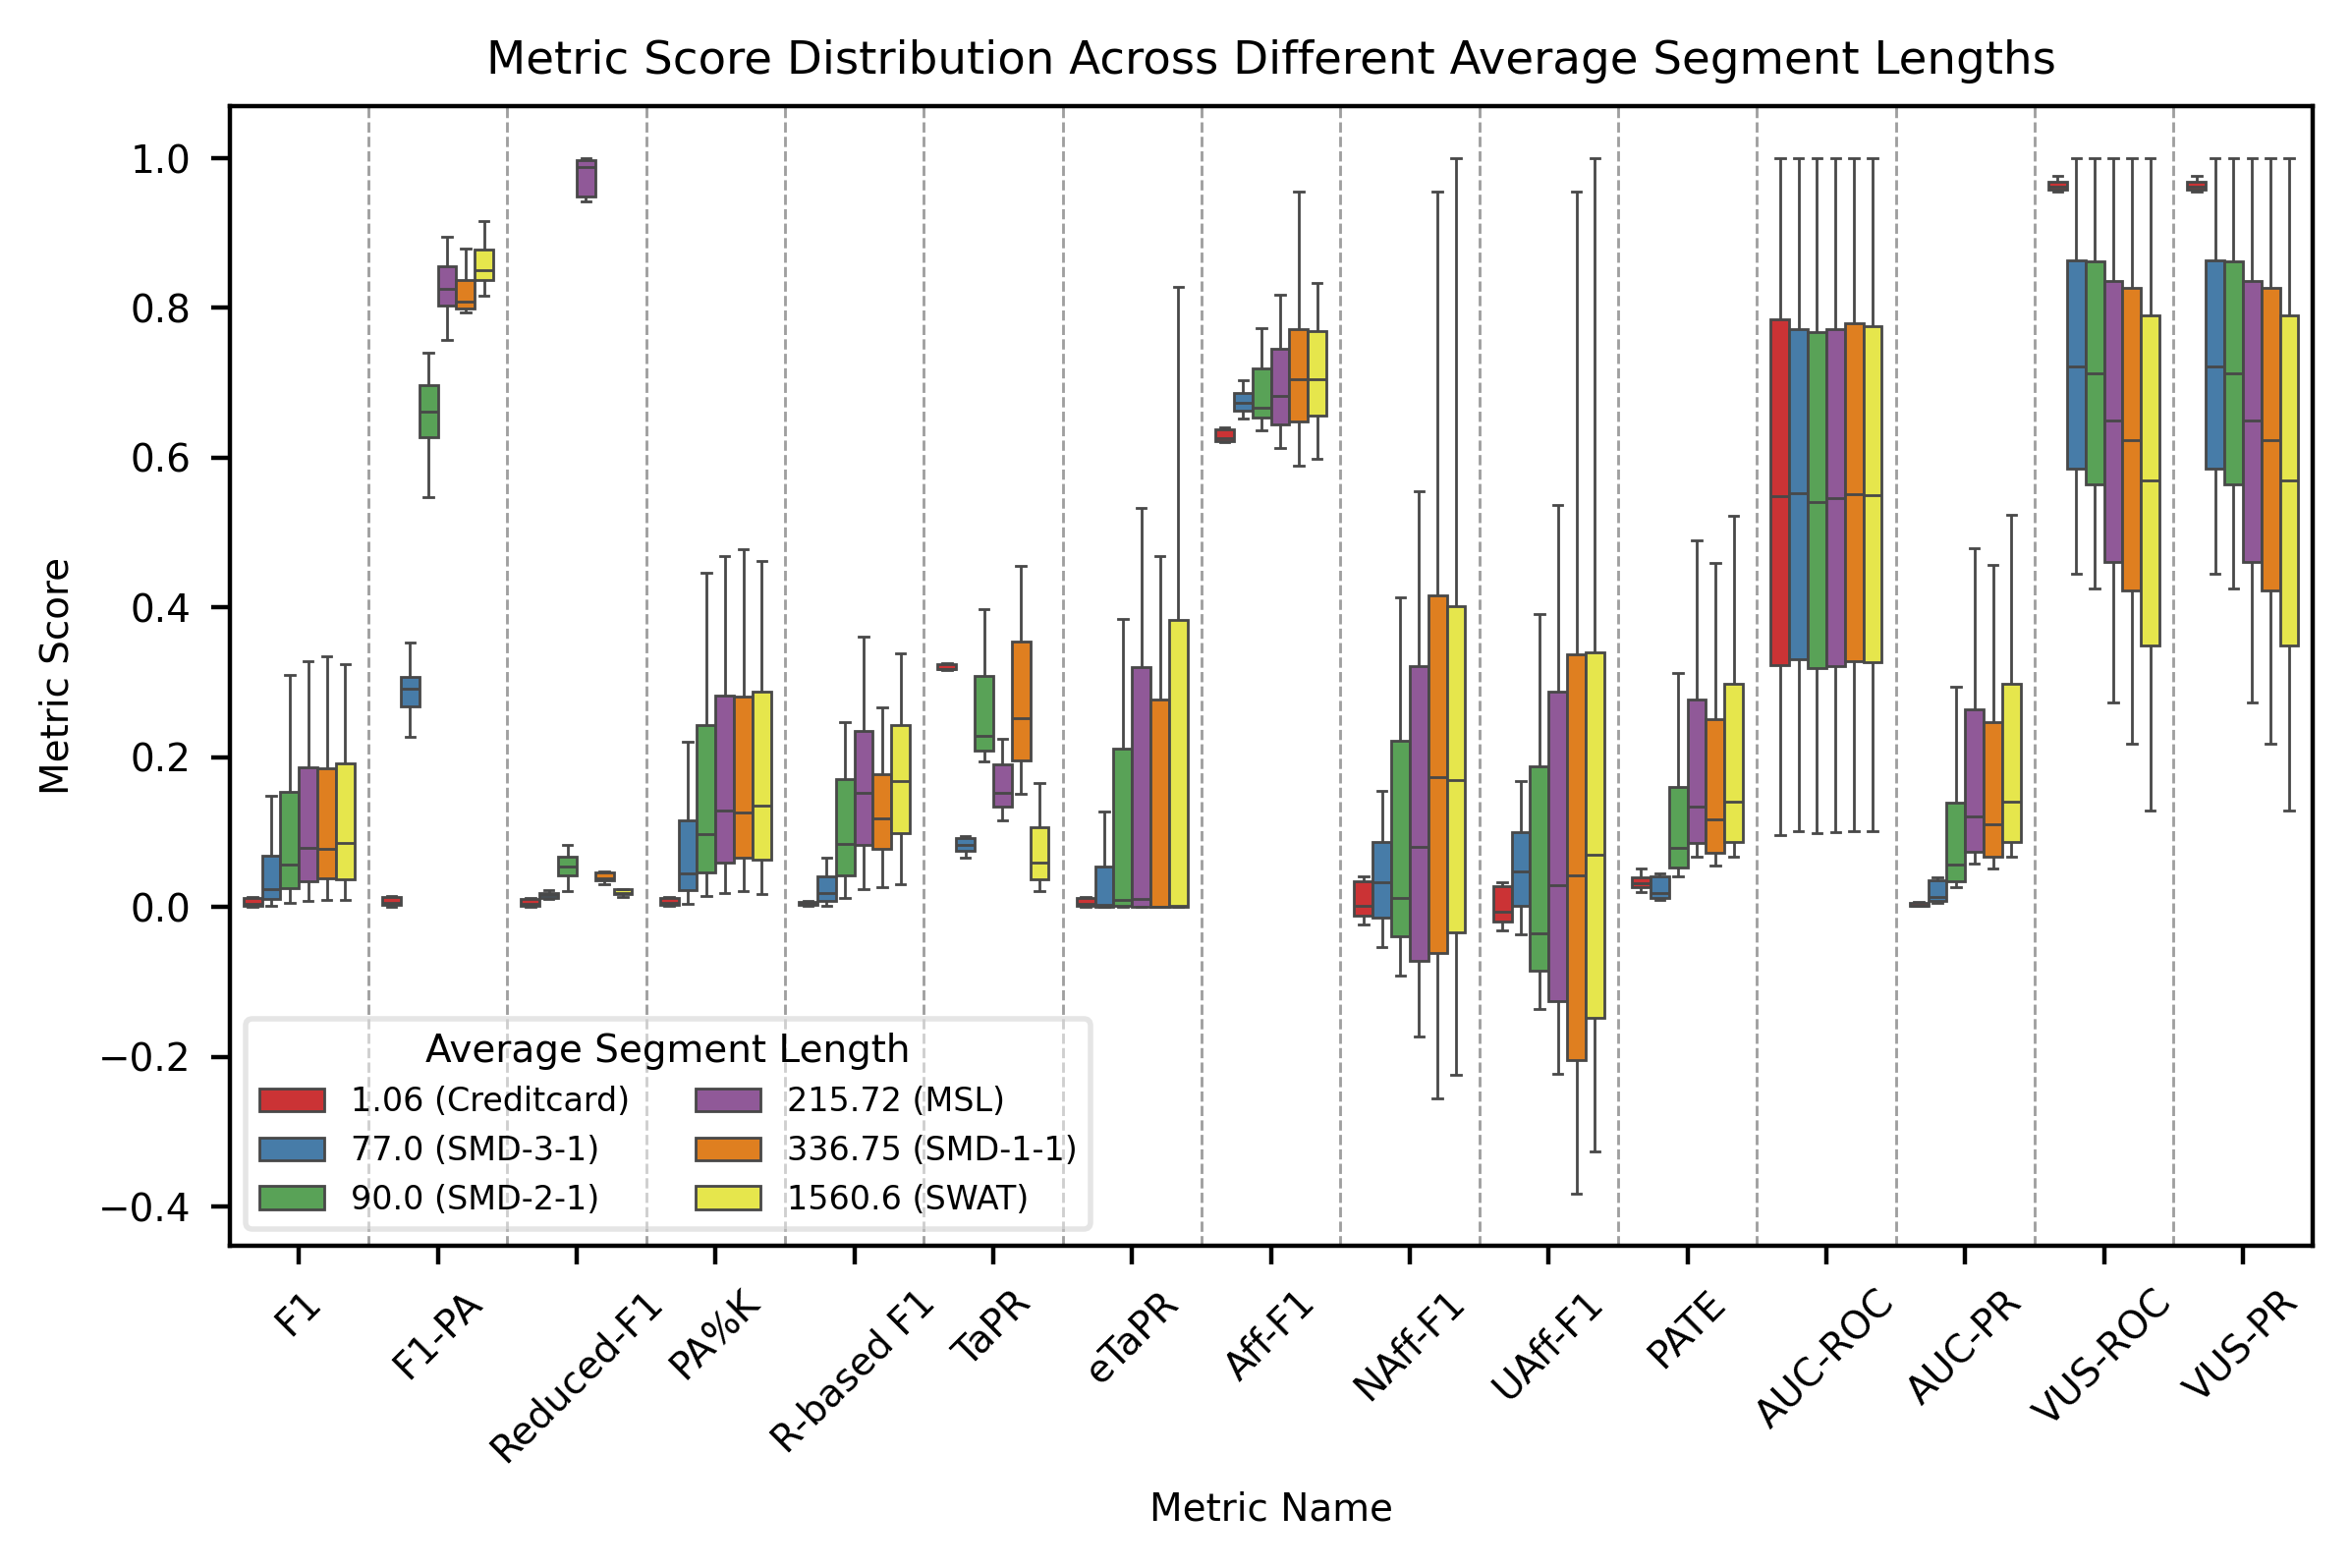

In [6]:
def plot_latency_distribution2(data_new, ver=1):
    df = data_new.copy()

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    seg_type = df['seg_type'].unique()
    seg_avg_len = df['avg_seg_len'].unique()
    data_name = df['case_name'].unique()
    ts_len = df['ts_len'].unique()

    order_list = []
    if ver==1:
        out_name ='seg_val_real'
        for data_n, seg in zip(data_name, seg_list):
            order_list.append((seg, f'{seg} Segs ({data_n})'))
    elif ver==2:
        out_name = 'ts_len_val_real'
        for data_n, ts_len_ in zip(data_name, ts_len):
            # avg_len = round(avg_len, 2)
            order_list.append((ts_len_, f'{ts_len_} ({data_n})'))
    elif ver==3:
        out_name = 'seg_len_val_real'
        for data_n, seg, avg_len in zip(data_name, seg_list, seg_avg_len):
            avg_len_ = round(avg_len, 2)
            order_list.append((avg_len, f'{avg_len_} ({data_n})'))
            

    # print(seg_list, seg_type, data_name)
    order_list = sorted(order_list, key=lambda x: x[0])
    print(order_list)
    seg_list = [x[0] for x in order_list]
    print(seg_list)
    legend_list = [x[1] for x in order_list]

    if ver==1:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                    order=metric_sort, 
                    hue='seg', 
                    hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1') 
    elif ver == 2:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                    order=metric_sort, 
                    hue='seg_type', 
                    # hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1') 
    elif ver == 3:
        plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                    order=metric_sort, 
                    hue='avg_seg_len', 
                    hue_order=seg_list,
                    showfliers=False,
                    linewidth=0.5,
                    palette='Set1')
        
    handles, labels = plot1_handle.get_legend_handles_labels()
    print(labels)
    # legend_title = 'Average Segment Length' if ver == 1 else 'Time Series Length'
    if ver == 1:
        legend_title = 'Segment'
    elif ver == 2:
        legend_title = 'Time Series Length'
    elif ver == 3:
        legend_title = 'Average Segment Length'
    # 设置新的图例标签
    plot1_handle.legend(handles, legend_list, title=legend_title, fontsize=6, loc='lower left', title_fontsize=7,
               framealpha=0.5,
               ncol=2)
    # 计算每个 seg 类别的位置
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    
    # plt.title(f'Metric Score Distribution')
    # if ver==1:
    #     plt.title(f'Metric Score Distribution Across Different Anomalous Segment Lengths')
    # elif ver==2:
    #     plt.title(f'Metric Score Distribution Across Different Time Series Lengths')

    if ver==1:
        plt.title(f'Metric Score Distribution Across Different Segment Counts')
    elif ver==2:
        plt.title(f'Metric Score Distribution Across Different Time Series Lengths')
    elif ver==3:
        plt.title(f'Metric Score Distribution Across Different Average Segment Lengths')

    plt.xlabel('Metric Name')
    plt.ylabel('Metric Score')
    # plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/{out_name}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments
plot_latency_distribution2(data_new,2)  # Plot for all segments
plot_latency_distribution2(data_new,3)  # Plot for all segments


/tmp/ipykernel_3934146/1545790629.py:30: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df,


    metric_name model_name      mean       std
31           F1   Model100  0.555451  0.315830
32           F1    Model20  0.012362  0.008387
33           F1    Model30  0.022022  0.013517
34           F1    Model40  0.032218  0.019690
35           F1    Model50  0.044919  0.028058
..          ...        ...       ...       ...
122      VUS-PR    Model20  0.474123  0.259335
123      VUS-PR    Model30  0.540438  0.224240
124      VUS-PR    Model40  0.606933  0.189299
125      VUS-PR    Model50  0.673785  0.154641
126      VUS-PR    Model60  0.739335  0.120573

[150 rows x 4 columns]


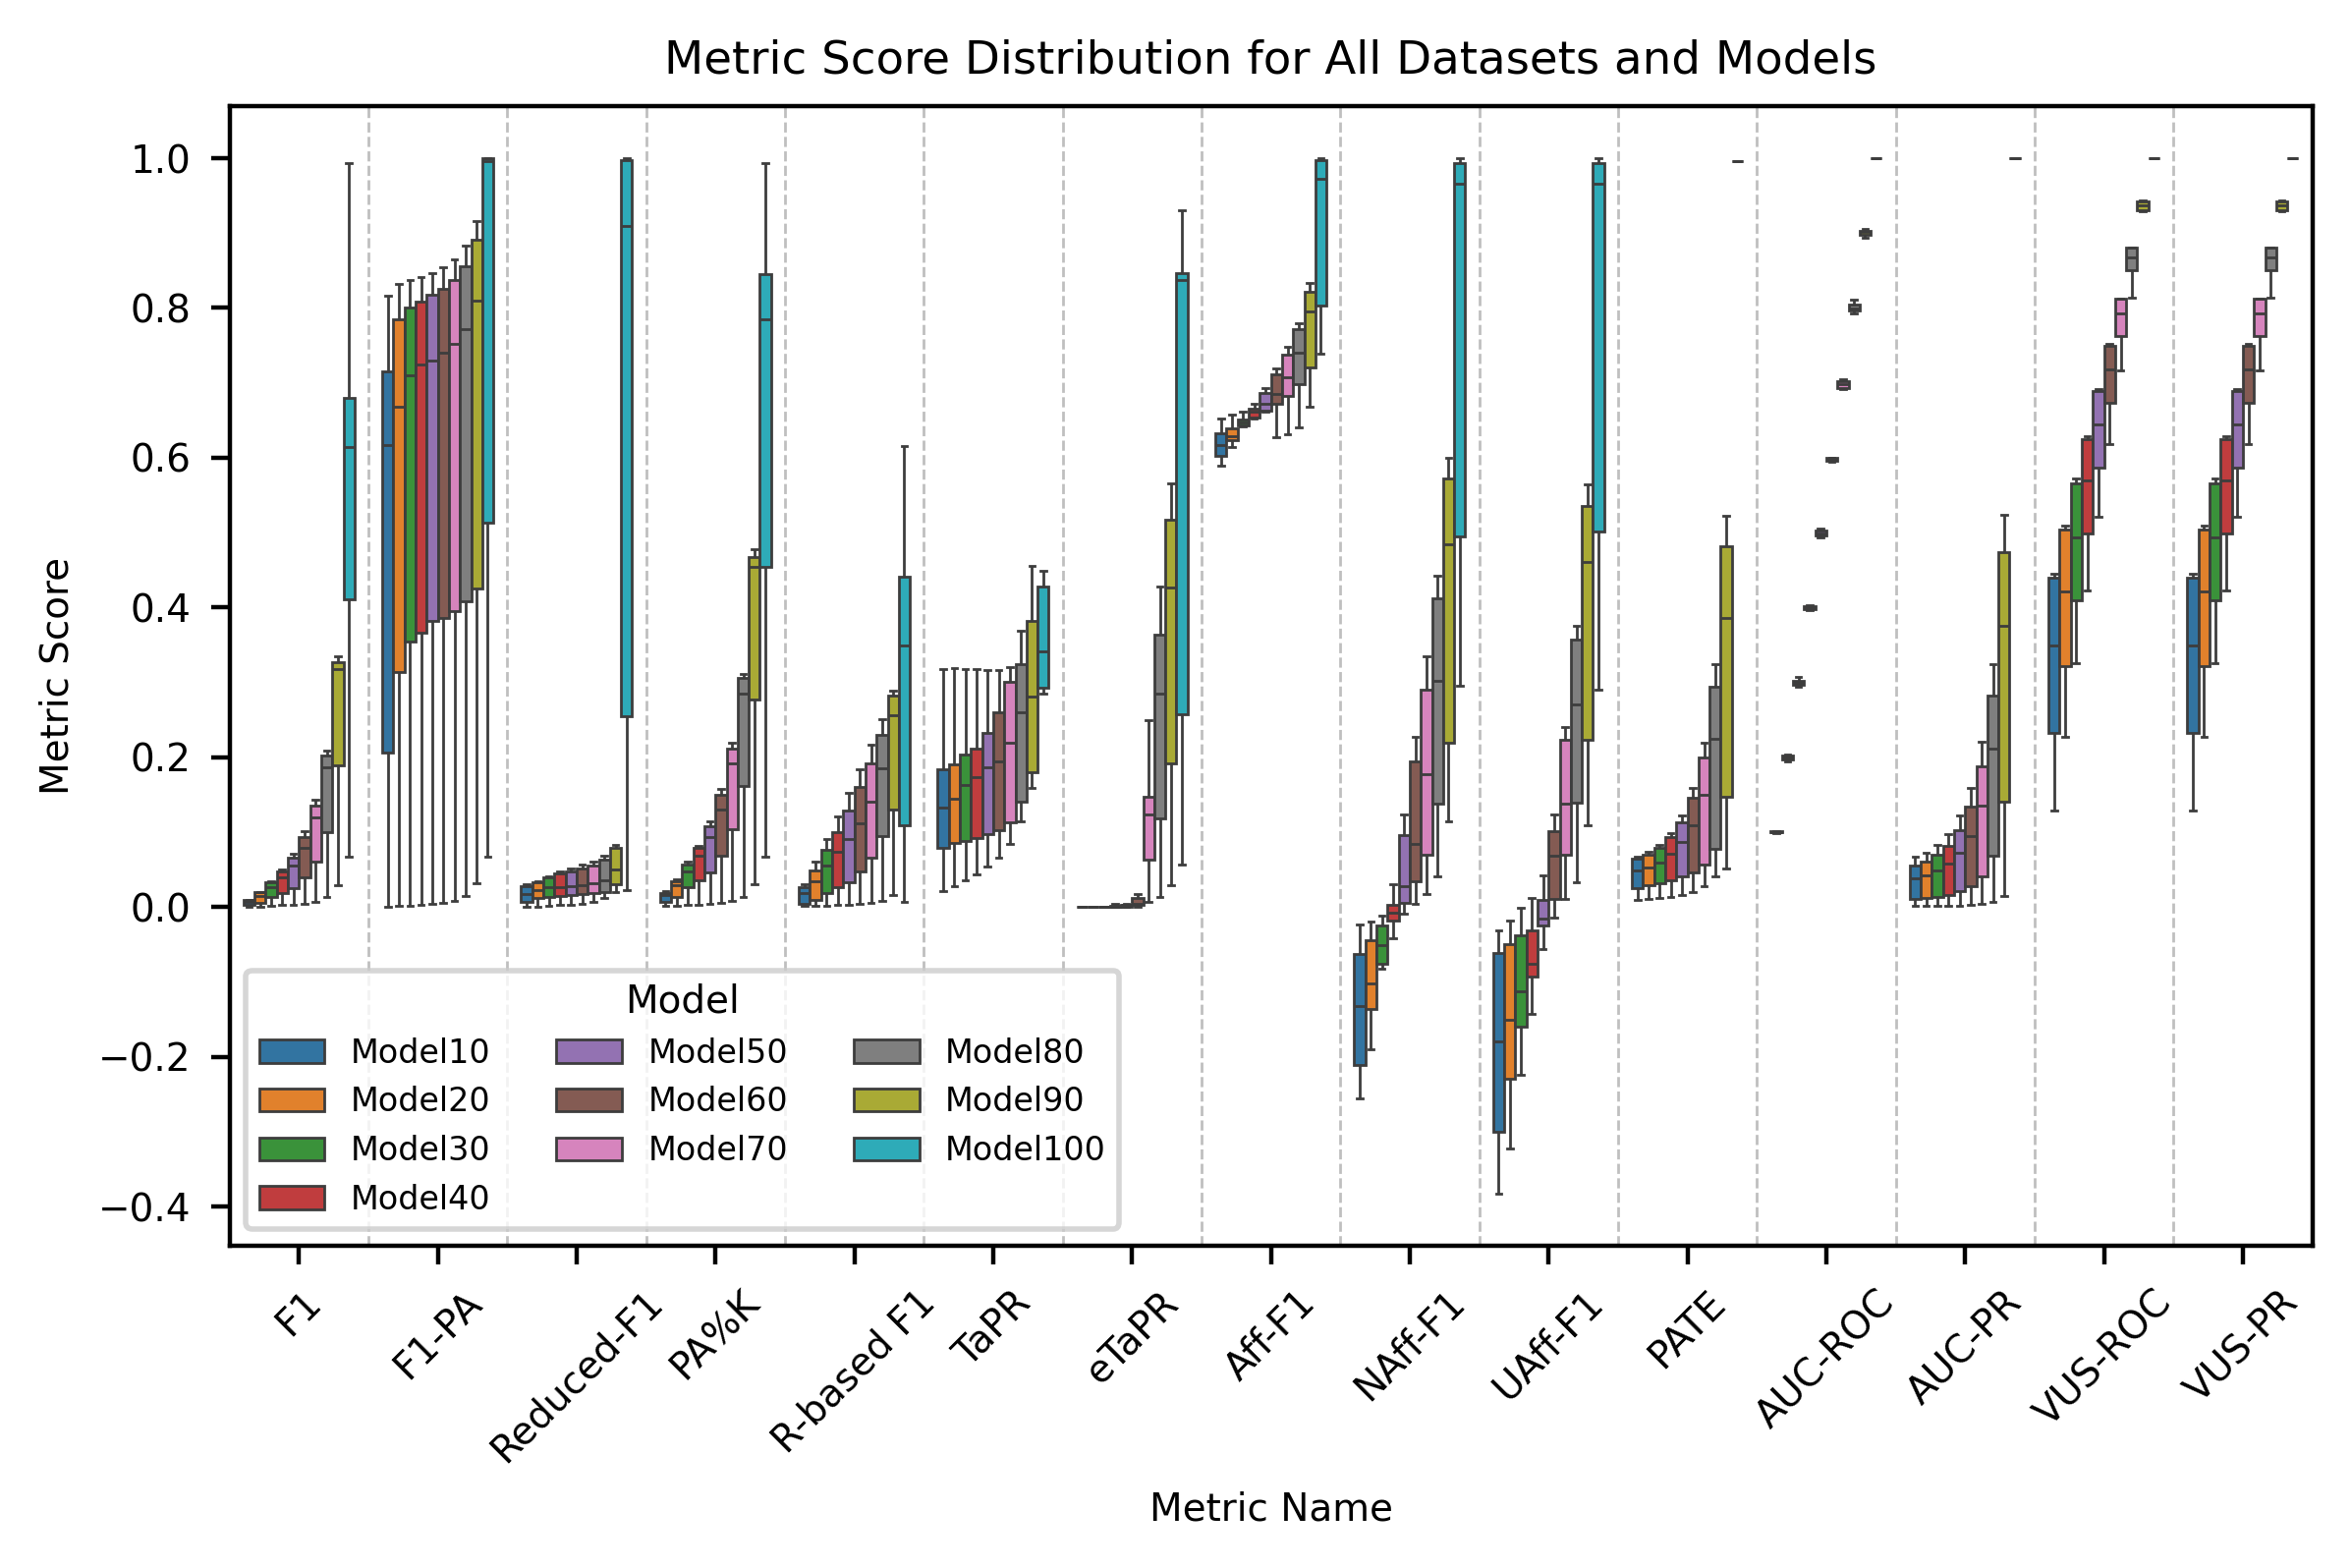

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm


def plot_latency_distribution3(data_new):
    df = data_new.copy()

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        if tmp.startswith('Model'):
            num_part = tmp.split('Model')[-1]
            return int(num_part)
        else:
            return -float('inf')
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    # custom_palette = cm.get_cmap('tab20').colors[:len(model_list)]
    # 定义一个包含足够多颜色的列表
    custom_palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
                  "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
                  "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_val'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    
    
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        
    # tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.legend(title='Model',
               loc='lower left', 
               fontsize=6, 
               title_fontsize=7,
               ncol=3)
    # plt.legend(title='Model')
    plt.title(f'Metric Score Distribution for All Datasets and Models')
    plt.xlabel('Metric Name')
    plt.ylabel('Metric Score')
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_val_real.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
# plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000